In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from afcharts.af_colours import get_af_colours

In [2]:
df = pd.read_csv('/Users/matthew/ONS/intro_to_python/2011.csv', header = 1)

In [ ]:
# Example of exisitng columns

df.head()

,Person ID,Region,Residence Type,Family Composition,Population Base,Sex,Age,Marital Status,Student,Country of Birth,Health,Ethnic Group,Religion,Economic Activity,Occupation,Industry,Hours worked per week,Approximated Social Grade
0,7394816,E12000001,H,2,1,2,6,2,2,1,2,1,2,5,8,2,-9,4
1,7394745,E12000001,H,5,1,1,4,1,2,1,1,1,2,1,8,6,4,3
2,7395066,E12000001,H,3,1,2,4,1,2,1,1,1,1,1,6,11,3,4
3,7395329,E12000001,H,3,1,2,2,1,2,1,2,1,2,1,7,7,3,2
4,7394712,E12000001,H,3,1,1,5,4,2,1,1,1,2,1,1,4,3,2


In [4]:
# Exploring the Sex column

df.groupby(["Sex"]).count()["Person ID"]

Sex
1    280569
2    289172
Name: Person ID, dtype: int64

In [5]:
# Setting up f_percent and m_percent column
# I used the sex_dict emthod form the Week 4 notes

sex_dict = {1: False, 2: True}

In [6]:
# Creating a 'Female' column

df['Female'] = df['Sex'].map(sex_dict)
df["Female"].head()

0     True
1    False
2     True
3     True
4    False
Name: Female, dtype: bool

In [7]:
# Filling in 'Male' column

df['Male'] = df['Sex'].map({1 : True, 2 : False})
df["Male"].head()

0    False
1     True
2    False
3    False
4     True
Name: Male, dtype: bool

In [ ]:
#Creatign labels for the 'Economic Activity' column

eco_dict = {1 : "Active: Employee", 
            2 : "Active: Self-employed", 
            3 : "Active: Unemployed", 
            4 : "Active: Full-time student",
            5 : "Inactive: Retired", 
            6 : "Inactive: Student", 
            7 : "Inactive: Looking after home", 
            8 : "Inactive: Disabled",
            9 : "Inactive: Other",
            -9: "No code required"}

# Labelling 'Economic Actvity' column

df['Eco. Activity Category'] = df['Economic Activity'].map(eco_dict)
df["Eco. Activity Category"].head()

0    Inactive: Retired
1     Active: Employee
2     Active: Employee
3     Active: Employee
4     Active: Employee
Name: Eco. Activity Category, dtype: str

In [9]:
# Creating summations of Sex columns

df_sum = df[["Eco. Activity Category", "Female", "Male"]] .groupby(["Eco. Activity Category"]).sum()
df_sum

,Female,Male
Eco. Activity Category,,
Active: Employee,108028,107997
Active: Full-time student,7530,6587
Active: Self-employed,11842,28790
Active: Unemployed,7349,10760
Inactive: Disabled,8769,9222
Inactive: Looking after home,16230,1715
Inactive: Other,5604,4464
Inactive: Retired,56875,40605
Inactive: Student,12136,12620


In [10]:
# Get the categorical palette hex codes
cat = get_af_colours("categorical")

# Get the sequential palette hex codes
seq = get_af_colours("sequential")
seq

['#12436D', '#2073BC', '#6BACE6']

In [11]:
# Applying style guidance to plots

plt.style.use('afcharts.afcharts')

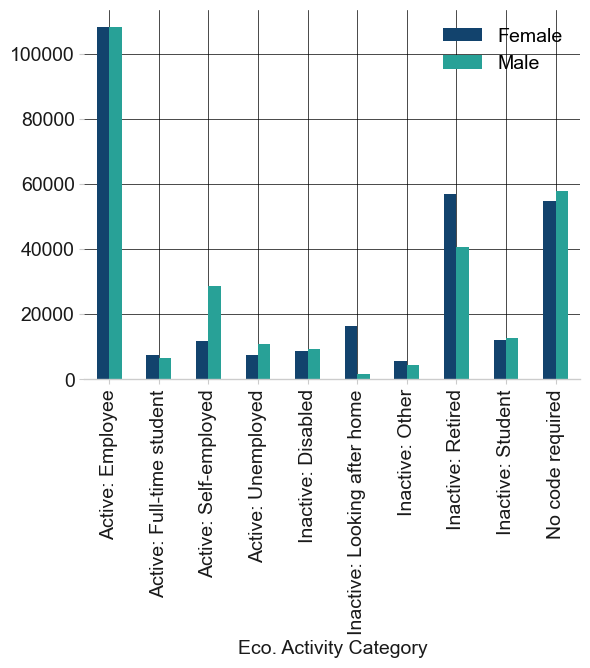

In [12]:
# Sex differences among unemployed employed and self-employed individuals 

df_sum.plot(kind = 'bar')
plt.grid(color = "k", linewidth = 0.5)

In [13]:
# Restrict to economically active (1, 2, 3), using tools that we have before

df_active_eco_sex = df[df['Eco. Activity Category'].isin(["Active: Employee", "Active: Self-employed", "Active: Unemployed", ])]
df_active_eco_sex.head()

,Person ID,Region,Residence Type,Family Composition,Population Base,Sex,Age,Marital Status,Student,Country of Birth,...,Ethnic Group,Religion,Economic Activity,Occupation,Industry,Hours worked per week,Approximated Social Grade,Female,Male,Eco. Activity Category
1,7394745,E12000001,H,5,1,1,4,1,2,1,...,1,2,1,8,6,4,3,False,True,Active: Employee
2,7395066,E12000001,H,3,1,2,4,1,2,1,...,1,1,1,6,11,3,4,True,False,Active: Employee
3,7395329,E12000001,H,3,1,2,2,1,2,1,...,1,2,1,7,7,3,2,True,False,Active: Employee
4,7394712,E12000001,H,3,1,1,5,4,2,1,...,1,2,1,1,4,3,2,False,True,Active: Employee
5,7394750,E12000001,H,2,1,1,6,2,2,1,...,1,1,1,9,2,3,3,False,True,Active: Employee


In [14]:
# 

active_ecos = df['Eco. Activity Category'][df['Eco. Activity Category'].str.startswith('Active')].unique()

list(active_ecos)

['Active: Employee',
 'Active: Full-time student',
 'Active: Self-employed',
 'Active: Unemployed']

In [15]:
# Setting new headers for future plots

df_active_eco_sex["Sex Headers"] = df_active_eco_sex["Sex"].map({1 : "Female", 2 : "Male"})
df_active_eco_sex.info()

<class 'pandas.DataFrame'>
Index: 274766 entries, 1 to 569740
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   Person ID                  274766 non-null  int64
 1   Region                     274766 non-null  str  
 2   Residence Type             274766 non-null  str  
 3   Family Composition         274766 non-null  int64
 4   Population Base            274766 non-null  int64
 5   Sex                        274766 non-null  int64
 6   Age                        274766 non-null  int64
 7   Marital Status             274766 non-null  int64
 8   Student                    274766 non-null  int64
 9   Country of Birth           274766 non-null  int64
 10  Health                     274766 non-null  int64
 11  Ethnic Group               274766 non-null  int64
 12  Religion                   274766 non-null  int64
 13  Economic Activity          274766 non-null  int64
 14  Occupation          

In [16]:
# Grouping active population together by sex

gb_active_eco_sex = df_active_eco_sex.groupby(["Eco. Activity Category", "Sex Headers"]).size().unstack()
gb_active_eco_sex

Sex Headers,Female,Male
Eco. Activity Category,,
Active: Employee,107997,108028
Active: Self-employed,28790,11842
Active: Unemployed,10760,7349


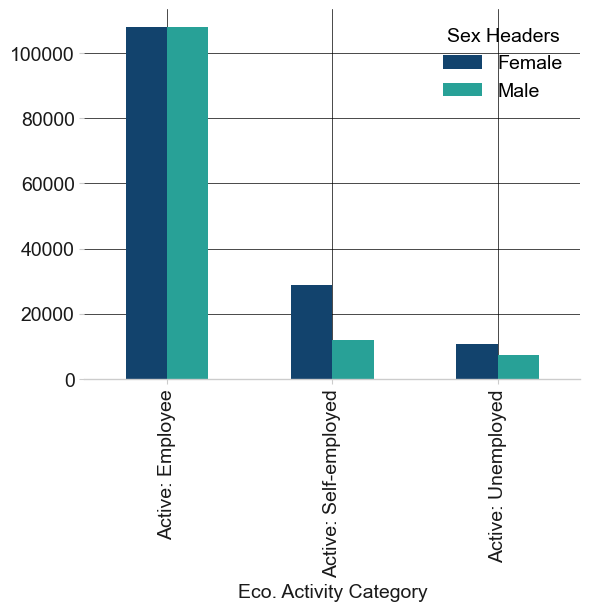

In [17]:
# Plot active people by sex

with plt.style.context('afcharts.afcharts'):
    gb_active_eco_sex[["Female", "Male"]] .plot(kind = 'bar')
    plt.grid(color = "k", linewidth = 0.5)

In [18]:
# Create sum column

gb_active_eco_sex["people_sum"] = gb_active_eco_sex["Female"] + gb_active_eco_sex["Male"]
gb_active_eco_sex

Sex Headers,Female,Male,people_sum
Eco. Activity Category,,,
Active: Employee,107997,108028,216025
Active: Self-employed,28790,11842,40632
Active: Unemployed,10760,7349,18109


In [19]:
gb_active_eco_sex['F_percent'] = 100 * gb_active_eco_sex['Female']/gb_active_eco_sex['people_sum']
gb_active_eco_sex['M_percent'] = 100 * gb_active_eco_sex['Male']/gb_active_eco_sex['people_sum']
gb_active_eco_sex

Sex Headers,Female,Male,people_sum,F_percent,M_percent
Eco. Activity Category,,,,,
Active: Employee,107997,108028,216025,49.992825,50.007175
Active: Self-employed,28790,11842,40632,70.855483,29.144517
Active: Unemployed,10760,7349,18109,59.417969,40.582031


In [20]:
# Textual representation of the data

pd.options.display.float_format = '{:.1f}'.format
gb_active_eco_sex[["F_percent", "M_percent"]]


Sex Headers,F_percent,M_percent
Eco. Activity Category,,
Active: Employee,50.0,50.0
Active: Self-employed,70.9,29.1
Active: Unemployed,59.4,40.6


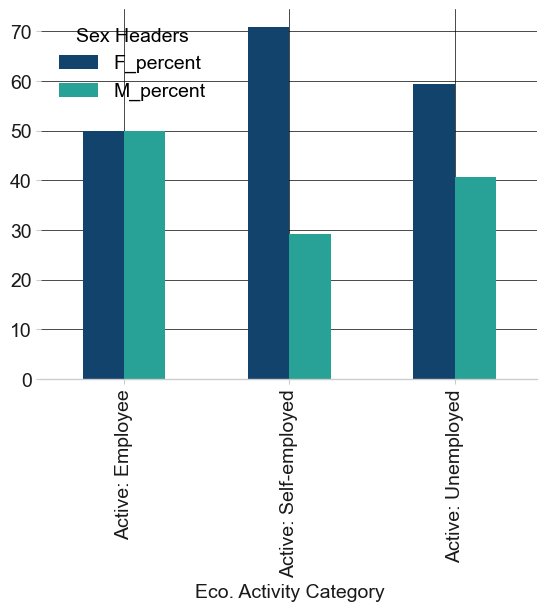

In [21]:
# Plot percentage fo each sex by activity

with plt.style.context('afcharts.afcharts'):
    gb_active_eco_sex[['F_percent', 'M_percent']].plot(kind = 'bar')
    plt.grid(color = "k", linewidth = 0.5)

In [22]:
# Figure 2 stuff

# Remoibng afcharts adn all effects doenst seem to amek any difference

In [ ]:
# 

gb_work_hrs_sex = df_active_eco_sex.groupby(["Hours Worked Per Week", "Sex Headers"]).size().unstack()

gb_work_hrs_sex

KeyError: 'Hours Worked Per Week'